# Level 1 — Task 2: Exploratory Data Analysis (EDA)
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `1_iris.csv` | **Tools:** Python, pandas, matplotlib, seaborn
>
> **Objective:** Calculate summary statistics, visualize distributions with histograms/boxplots/scatter plots, and find correlations between features.


## Step 1 — Imports and Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 120
})

os.makedirs("outputs/level1/eda_plots", exist_ok=True)

print("Ready.")

Ready.


## Step 2 — Load the Dataset

In [5]:
df = pd.read_csv("1_iris.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3 — Summary Statistics

Calculate **mean, median, mode, standard deviation** globally and per species.

In [6]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
stats = df[numeric_cols].agg(["mean", "median", "std", "min", "max"])
stats.loc["mode"] = df[numeric_cols].mode().iloc[0]
print("Global statistics:")
stats.round(3)

Global statistics:


,sepal_length,sepal_width,petal_length,petal_width
mean,5.843,3.054,3.759,1.199
median,5.800,3.000,4.350,1.300
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
max,7.900,4.400,6.900,2.500
mode,5.000,3.000,1.500,0.200


In [7]:
print("Statistics grouped by species:")
df.groupby("species")[numeric_cols].agg(["mean","std"]).round(3)

Statistics grouped by species:


sepal_length        sepal_width        petal_length         \
                   mean    std        mean    std         mean    std   
species                                                                 
setosa            5.006  0.352       3.418  0.381        1.464  0.174   
versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
virginica         6.588  0.636       2.974  0.322        5.552  0.552   

           petal_width         
                  mean    std  
species                        
setosa           0.244  0.107  
versicolor       1.326  0.198  
virginica        2.026  0.275

In [8]:
print("Species distribution:")
df["species"].value_counts()

Species distribution:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## Step 4 — Histograms (Distribution per Feature)

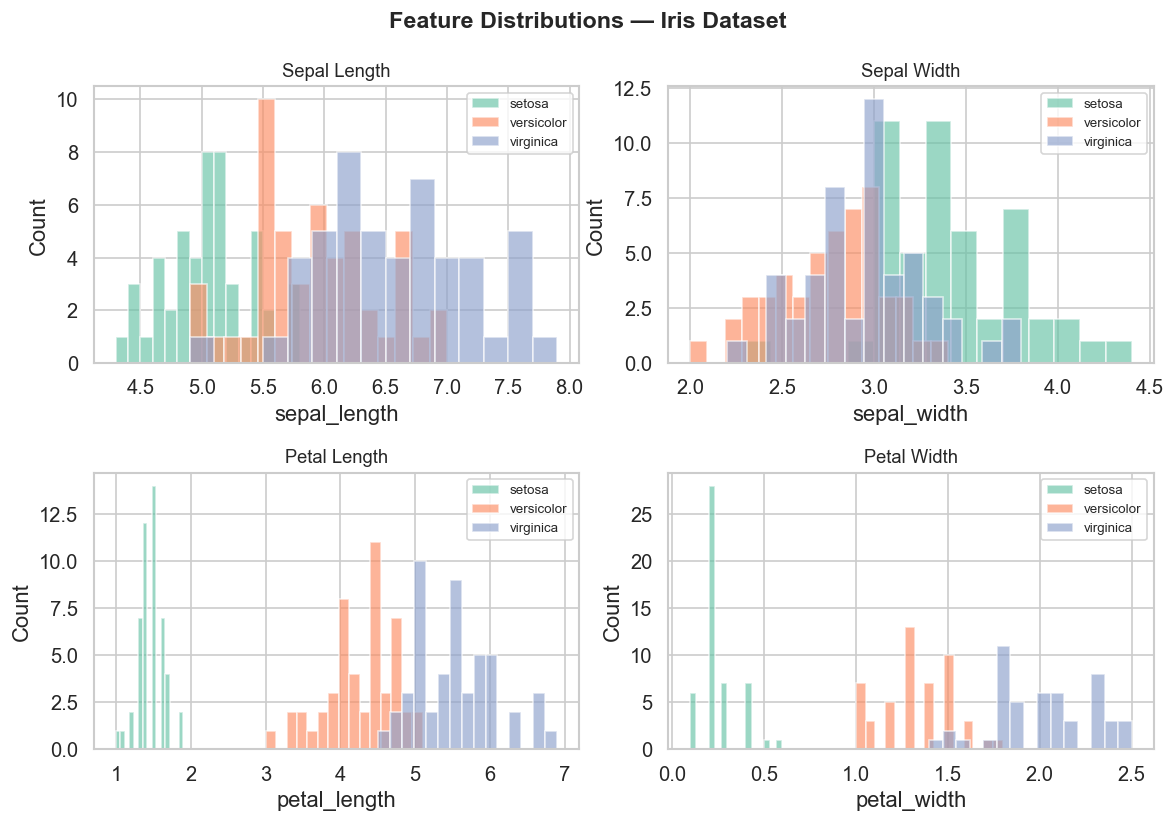

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Feature Distributions — Iris Dataset", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), numeric_cols):
    for species, group in df.groupby("species"):
        ax.hist(group[col], bins=15, alpha=0.65, label=species, edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel("Count"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/level1/eda_plots/histograms.png")
plt.show()

## Step 5 — Boxplots (Spread and Outliers per Species)

C:\Users\Ibrahim\AppData\Local\Temp\ipykernel_9680\2582720730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y=col, data=df, ax=ax, palette="Set2",
C:\Users\Ibrahim\AppData\Local\Temp\ipykernel_9680\2582720730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y=col, data=df, ax=ax, palette="Set2",
C:\Users\Ibrahim\AppData\Local\Temp\ipykernel_9680\2582720730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y=col, data=df, ax=ax, palette="Set2",
C:\Users\Ibrahim\AppData\Local\Temp\ipykernel_968

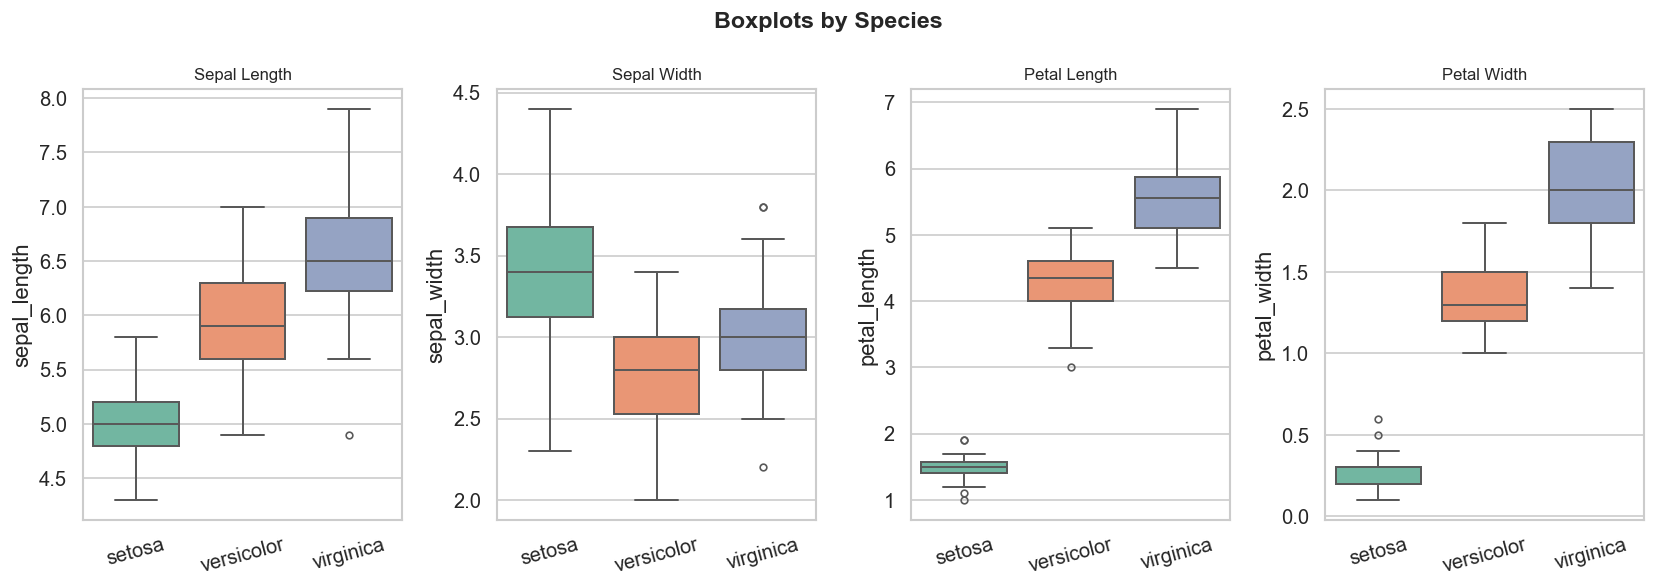

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle("Boxplots by Species", fontsize=14, fontweight="bold")

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x="species", y=col, data=df, ax=ax, palette="Set2",
                linewidth=1.2, flierprops=dict(marker="o", markersize=4))
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("outputs/level1/eda_plots/boxplots.png")
plt.show()

## Step 6 — Scatter Plots (Feature Relationships)

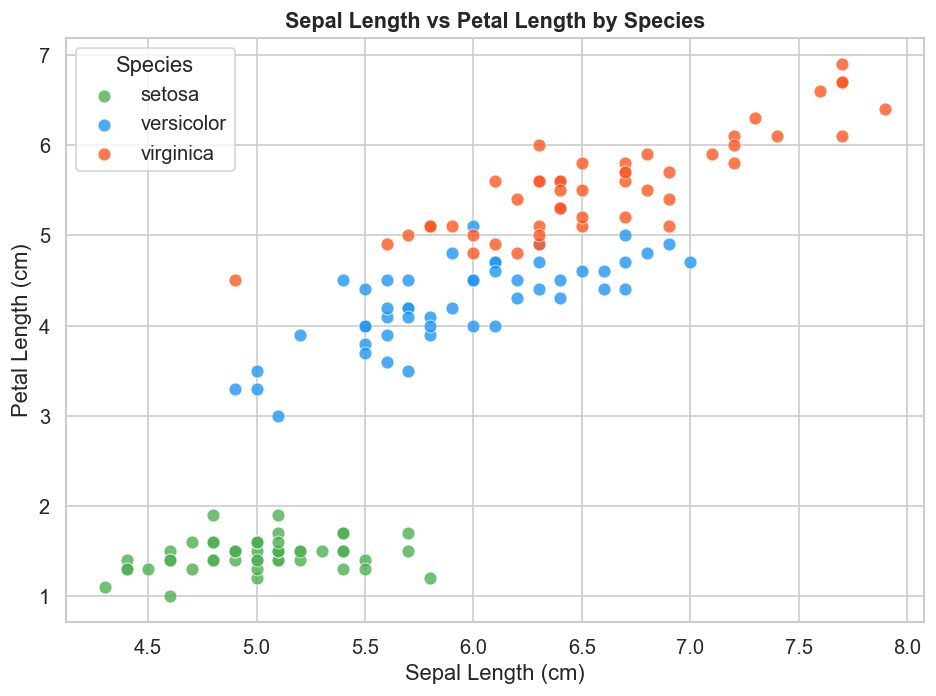

In [11]:
SPECIES_COLORS = {"setosa": "#4CAF50", "versicolor": "#2196F3", "virginica": "#FF5722"}

fig, ax = plt.subplots(figsize=(8, 6))
for species, color in SPECIES_COLORS.items():
    subset = df[df["species"] == species]
    ax.scatter(subset["sepal_length"], subset["petal_length"],
               label=species, color=color, s=60, alpha=0.8,
               edgecolors="white", linewidths=0.5)
ax.set_xlabel("Sepal Length (cm)"); ax.set_ylabel("Petal Length (cm)")
ax.set_title("Sepal Length vs Petal Length by Species", fontsize=13, fontweight="bold")
ax.legend(title="Species")
plt.tight_layout()
plt.savefig("outputs/level1/eda_plots/scatter_sepal_vs_petal.png")
plt.show()

## Step 7 — Pairplot (All Feature Combinations)

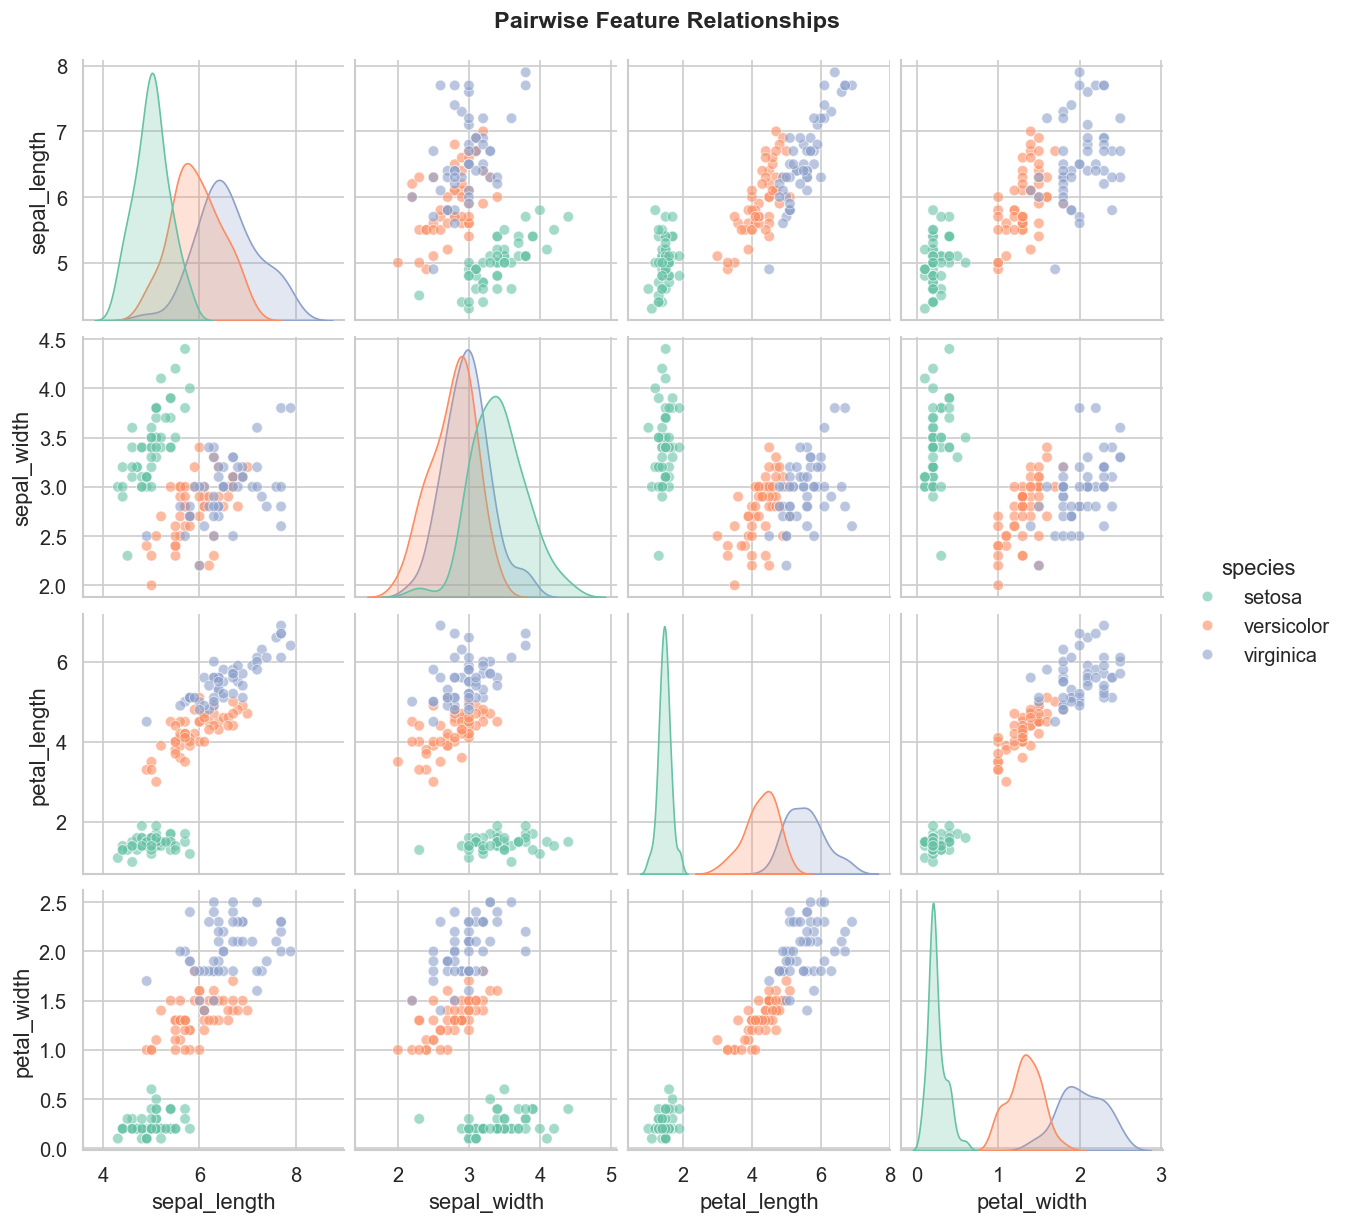

In [12]:
pairplot = sns.pairplot(df, hue="species", palette="Set2",
                        diag_kind="kde", plot_kws={"alpha": 0.6, "s": 40})
pairplot.fig.suptitle("Pairwise Feature Relationships", y=1.02,
                       fontsize=14, fontweight="bold")
plt.savefig("outputs/level1/eda_plots/pairplot.png")
plt.show()

## Step 8 — Correlation Heatmap

In [13]:
corr_matrix = df[numeric_cols].corr()
print("Correlation matrix:")
print(corr_matrix.round(3))

Correlation matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.109         0.872        0.818
sepal_width         -0.109        1.000        -0.421       -0.357
petal_length         0.872       -0.421         1.000        0.963
petal_width          0.818       -0.357         0.963        1.000


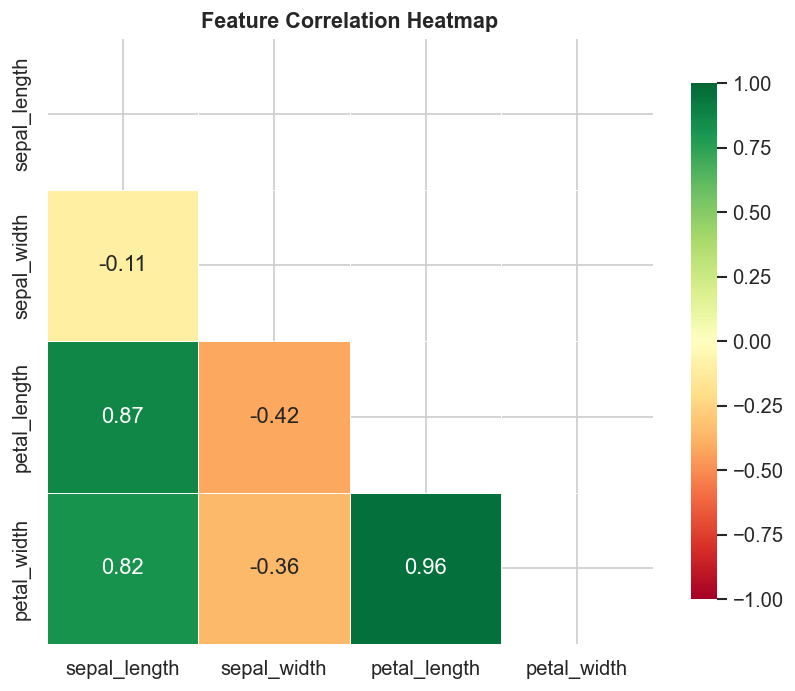

In [14]:
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/level1/eda_plots/correlation_heatmap.png")
plt.show()

## Step 9 — Key EDA Insights

In [15]:
insights = [
    "Dataset: 150 samples, 50 per species — perfectly balanced.",
    "Setosa is clearly separable from the other two species on petal features.",
    "petal_length & petal_width are highly correlated (r ≈ 0.96).",
    "sepal_length & petal_length are also strongly correlated (r ≈ 0.87).",
    "sepal_width shows the weakest species discriminative power.",
    "Virginica has the largest petal dimensions on average.",
    "Petal features are the best candidates for species classification.",
]
print("EDA KEY FINDINGS")
print("=" * 50)
for i, ins in enumerate(insights, 1):
    print(f"  {i}. {ins}")

EDA KEY FINDINGS
  1. Dataset: 150 samples, 50 per species — perfectly balanced.
  2. Setosa is clearly separable from the other two species on petal features.
  3. petal_length & petal_width are highly correlated (r ≈ 0.96).
  4. sepal_length & petal_length are also strongly correlated (r ≈ 0.87).
  5. sepal_width shows the weakest species discriminative power.
  6. Virginica has the largest petal dimensions on average.
  7. Petal features are the best candidates for species classification.
